<!-- Trabalho Desenvolvido na Data Science Academy - www.datascienceacademy.com.br -->
# <font color='blue'>Data Science Academy</font>
# <font color='blue'>Fundamentos de Linguagem Python - Do Básico a Aplicações de IA</font>
# <font color='blue'>Lista 5 de Exercícios</font>

**ATENÇÃO**: Esta lista de exercícios pode requerer pesquisa complementar. A solução será apresentada no próximo capítulo.

In [1]:
# Imports
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display, Markdown

#### Exercício 1: Análise de Distribuição de Receita Mensal

- Contexto: Uma loja online deseja entender a variabilidade das receitas mensais para ajustar seu fluxo de caixa.

- Tarefa: Carregue os dados simulados de receita mensal e apresente um relatório com média, mediana, desvio-padrão, assimetria e curtose. Visualize a distribuição e interprete se ela é simétrica, à direita ou à esquerda.

- Resultado esperado: Descreva a tendência central e a dispersão, comente se a média representa bem o conjunto.

In [2]:
# Seed
np.random.seed(10)

# Cria dados de receita
receita = np.random.normal(50000, 8000, 100)

# Cria o dataframe
df = pd.DataFrame({'Receita': receita})

# Visualiza os dados
df.head()

,Receita
0,60652.692033
1,55722.231795
2,37636.797663
3,49932.929201
4,54970.687791


In [3]:
# Solução

# Estatísticas
media = df['Receita'].mean()
mediana = df['Receita'].median()
desvio_padrao = df['Receita'].std()
assimetria = df['Receita'].skew()
curtose = df['Receita'].kurtosis()

# Relatório
print("===== RELATÓRIO DE RECEITA MENSAL =====")
print(f"Média:          R$ {media:,.2f}")
print(f"Mediana:        R$ {mediana:,.2f}")
print(f"Desvio-padrão:  R$ {desvio_padrao:,.2f}")
print(f"Assimetria:     {assimetria:.4f}")
print(f"Curtose:        {curtose:.4f}")
print(f"Mínimo:         R$ {df['Receita'].min():,.2f}")
print(f"Máximo:         R$ {df['Receita'].max():,.2f}")

===== RELATÓRIO DE RECEITA MENSAL =====
Média:          R$ 50,635.33
Mediana:        R$ 50,754.95
Desvio-padrão:  R$ 7,775.29
Assimetria:     0.0138
Curtose:        0.1935
Mínimo:         R$ 32,946.30
Máximo:         R$ 69,741.21


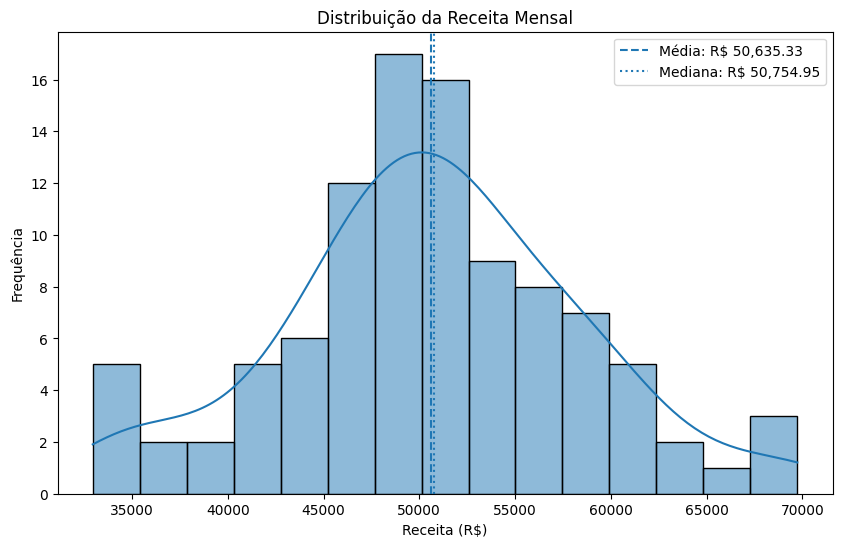

In [4]:
# Visualização
plt.figure(figsize=(10, 6))

sns.histplot(
    df['Receita'],
    kde=True,
    bins=15
)

plt.axvline(
    media,
    linestyle='--',
    label=f'Média: R$ {media:,.2f}'
)

plt.axvline(
    mediana,
    linestyle=':',
    label=f'Mediana: R$ {mediana:,.2f}'
)

plt.title('Distribuição da Receita Mensal')
plt.xlabel('Receita (R$)')
plt.ylabel('Frequência')
plt.legend()
plt.show()

In [5]:
display(Markdown("""
# Tendência central:
A receita média foi de aproximadamente *50,6* mil reais por mês, enquanto a mediana foi de *50,8* mil reais. Como os dois valores são muito próximos, não há evidência de que valores extremos estejam distorcendo significativamente a média.

# Dispersão:
O desvio-padrão foi de aproximadamente *7,8 mil* reais. Isso indica uma variabilidade considerável em torno da receita média. O coeficiente de variação é de aproximadamente 15,3%, indicando uma dispersão moderada.

# Assimetria:
A assimetria foi *0,0138*, praticamente zero. Portanto, a distribuição é aproximadamente simétrica, sem uma cauda relevante para a direita ou para a esquerda.

# Curtose:
A curtose em excesso foi *0,1935*, próxima de zero. Isso indica uma distribuição relativamente próxima da normal, com uma concentração e presença de valores extremos semelhantes às de uma distribuição normal, embora ligeiramente mais leptocúrtica.
"""))


# Tendência central:
A receita média foi de aproximadamente *50,6* mil reais por mês, enquanto a mediana foi de *50,8* mil reais. Como os dois valores são muito próximos, não há evidência de que valores extremos estejam distorcendo significativamente a média.

# Dispersão:
O desvio-padrão foi de aproximadamente *7,8 mil* reais. Isso indica uma variabilidade considerável em torno da receita média. O coeficiente de variação é de aproximadamente 15,3%, indicando uma dispersão moderada.

# Assimetria:
A assimetria foi *0,0138*, praticamente zero. Portanto, a distribuição é aproximadamente simétrica, sem uma cauda relevante para a direita ou para a esquerda.

# Curtose:
A curtose em excesso foi *0,1935*, próxima de zero. Isso indica uma distribuição relativamente próxima da normal, com uma concentração e presença de valores extremos semelhantes às de uma distribuição normal, embora ligeiramente mais leptocúrtica.


#### Exercício 2: Desempenho por Segmento de Cliente

- Contexto: Uma empresa quer comparar o valor médio gasto por clientes novos e antigos.

- Tarefa: Para os dois grupos (clientes novos e antigos), calcule média, mediana e desvio-padrão, e compare visualmente com boxplot. Discuta se há sobreposição entre os grupos e qual apresenta maior variabilidade.

- Resultado esperado: Indique diferenças de média e dispersão, e o que isso sugere sobre o perfil de gasto.

In [6]:
# Seed
np.random.seed(5)

# Dataframe
clientes = pd.DataFrame({
    'Grupo': ['Novo']*80 + ['Antigo']*80,
    'Gasto': np.concatenate([np.random.normal(180, 40, 80),
                             np.random.normal(230, 35, 80)])
})

# Visualiza os dados
clientes.sample(10)

,Grupo,Gasto
122,Antigo,216.853270
119,Antigo,229.406914
143,Antigo,207.787163
40,Novo,167.765879
4,Novo,184.384394
27,Novo,165.467565
150,Antigo,279.075832
106,Antigo,200.373598
82,Antigo,256.100443
50,Novo,236.535921


In [7]:
# Solução


#### Exercício 3: Correlação Entre Horas de Estudo e Nota

- Contexto: Um professor quer saber se o tempo de estudo está associado ao desempenho dos alunos.

- Tarefa: Calcule a correlação de Pearson e gere o gráfico de dispersão com linha de regressão. Interprete o grau e a direção da relação.

- Resultado esperado: Descreva se há correlação positiva, negativa ou nula e o que isso significa em termos práticos.

In [8]:
# Seed
np.random.seed(2)

# Dados
horas = np.random.uniform(1, 10, 50)
notas = 5*horas + np.random.normal(0, 5, 50)

# Dataframe
df = pd.DataFrame({'Horas': horas, 'Nota': notas})

# Visualiza os dados
df.head()

,Horas,Nota
0,4.923954,20.474094
1,1.233336,6.605232
2,5.946962,34.736641
3,4.917902,22.684045
4,4.783310,22.038204


In [9]:
# Solução


#### Exercício 4: Variação Semanal de Vendas

- Contexto: O gestor deseja entender como as vendas variam ao longo da semana.

- Tarefa: Simule dados de vendas diárias, calcule média e desvio por dia da semana e gere um gráfico de barras. Interprete os dias de maior e menor performance.

- Resultado esperado: Identifique os dias mais fortes e mais fracos, e comente sobre a estabilidade semanal das vendas.

In [10]:
# Seed
np.random.seed(3)

# Dados
dias = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sab', 'Dom']
vendas = pd.DataFrame({
    'Dia': np.random.choice(dias, 200),
    'Vendas': np.random.normal(1000, 150, 200)
})

# Visualiza os dados
vendas.head()

,Dia,Vendas
0,Qua,911.338189
1,Seg,922.537395
2,Ter,856.000573
3,Qui,1056.594285
4,Seg,913.793737


In [11]:
# Solução


#### Exercício 5: Estimativa da Média com Intervalo de Confiança (Statsmodels)

- Contexto: Um analista de RH quer estimar a altura média dos colaboradores com 95% de confiança.

- Tarefa: Calcule a média e o intervalo de confiança usando o DescrStatsW do Statsmodels. Interprete o resultado como se fosse parte de um relatório técnico.

- Resultado esperado: Apresente a altura média estimada e explique o significado do intervalo de confiança no contexto da amostra.

In [12]:
# Seed
np.random.seed(7)

# Conjunto de dados
alturas = np.random.normal(1.75, 0.08, 40)

# Visualiza os dados
alturas

array([1.88524206, 1.71272501, 1.75262561, 1.7826013 , 1.68688616,
       1.75016525, 1.74992877, 1.60962206, 1.83141264, 1.79803988,
       1.69996568, 1.73627614, 1.79042395, 1.72909149, 1.73058007,
       1.63374069, 1.79436642, 1.75991047, 1.77195679, 1.62787804,
       1.88205598, 1.76234684, 1.7190288 , 1.91232578, 1.74636912,
       1.6339457 , 1.71758177, 1.56693479, 1.83395172, 1.71668205,
       1.69059572, 1.83579761, 1.61791395, 1.79283435, 1.58484682,
       1.69702725, 1.65366241, 1.86695805, 1.89129287, 1.7236469 ])

In [13]:
# Solução


# Fim